<a href="https://colab.research.google.com/github/AvniSriram/Sex-Specific-AD-Microglia/blob/main/code/Test_8_18_Behavioral_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
five_choice = pd.read_csv('/content/FB_AD_5Choice.csv')

In [ ]:
np.random.seed(42)

In [ ]:
five_choice.info()
five_choice.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8090 entries, 0 to 8089
Data columns (total 37 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   AnimalID                                         8090 non-null   object 
 1   Age                                              8090 non-null   object 
 2   Sex                                              8090 non-null   object 
 3   Genotype                                         8090 non-null   object 
 4   Strain                                           8090 non-null   object 
 5   ExpName                                          8090 non-null   object 
 6   Housing                                          8090 non-null   object 
 7   LightCycle                                       8090 non-null   object 
 8   PISiteUser                                       8090 non-null   object 
 9   SessionName                   

(8090, 37)

In [ ]:
print(five_choice['Genotype'].value_counts())

Genotype
C57BL/6J      1889
APP/PS1       1349
5XFAD         1280
3xTG-AD       1276
B6SJLF1/J     1275
B6129SF2/J    1021
Name: count, dtype: int64


In [ ]:
print("5Choice Genotypes:")
print(five_choice['Genotype'].unique())

5Choice Genotypes:
['5XFAD' 'B6SJLF1/J' 'B6129SF2/J' '3xTG-AD' 'C57BL/6J' 'APP/PS1']


In [ ]:
print(five_choice['Sex'].value_counts())

Sex
m    4088
f    4002
Name: count, dtype: int64


In [ ]:
def clean_behavior(df, metric_cols):
    df = df[df['Genotype'].isin(['5XFAD', 'C57BL/6J', 'B6129SF2/J'])]
    df = df[metric_cols]
    metric_only = [c for c in metric_cols if c not in ['AnimalID','Sex','Genotype','Strain','SessionName','Date_Time']]
    df['Sex'] = df['Sex'].replace({'M':'Male', 'F':'Female'})
    df['DiseaseStatus'] = df['Genotype'].apply(lambda g: 'AD' if g == '5XFAD' else 'Control')
    return df

five_choice_columns = [
    'AnimalID', 'Age', 'Sex', 'Genotype', 'Strain', 'SessionName', 'Date_Time',
    'AVG_Trial Analysis - Accuracy%',
    'AVG_Trial Analysis - Correct',
    'AVG_Trial Analysis - Incorrect',
    'AVG_Trial Analysis - Omission',
    'AVG_Trial Analysis - Omission%',
    'AVG_Trial Analysis - Premature',
    'AVG_Perseverative Correct - Total',
    'AVG_Perseverative Incorrect - Total',
    'AVG_Trial Analysis - Correct Response Latency',
    'AVG_Trial Analysis - Incorrect Response Latency',
    'AVG_Trial Analysis - Reward Collection Latency',
    'AVG_Threshold - Accuracy %',
    'AVG_Threshold - Omission %',
    'AVG_Threshold - Trials',
    'AVG_Threshold - Condition'
]

five_choice = clean_behavior(five_choice, five_choice_columns)

In [ ]:
print(five_choice['Genotype'].value_counts())

Genotype
C57BL/6J      1889
5XFAD         1280
B6129SF2/J    1021
Name: count, dtype: int64


In [ ]:
five_choice.isna().sum()

,0
AnimalID,0
Age,0
Sex,0
Genotype,0
Strain,0
SessionName,0
Date_Time,0
AVG_Trial Analysis - Accuracy%,6
AVG_Trial Analysis - Correct,6
AVG_Trial Analysis - Incorrect,100


In [ ]:
five_choice.info()
five_choice.shape

<class 'pandas.core.frame.DataFrame'>
Index: 4190 entries, 0 to 8088
Data columns (total 23 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   AnimalID                                         4190 non-null   object 
 1   Age                                              4190 non-null   object 
 2   Sex                                              4190 non-null   object 
 3   Genotype                                         4190 non-null   object 
 4   Strain                                           4190 non-null   object 
 5   SessionName                                      4190 non-null   object 
 6   Date_Time                                        4190 non-null   object 
 7   AVG_Trial Analysis - Accuracy%                   4184 non-null   float64
 8   AVG_Trial Analysis - Correct                     4184 non-null   float64
 9   AVG_Trial Analysis - Incorrect     

(4190, 23)

In [ ]:
five_choice_metrics = [
    'AVG_Trial Analysis - Accuracy%',
    'AVG_Trial Analysis - Omission%',
    'AVG_Trial Analysis - Correct Response Latency',
    'AVG_Trial Analysis - Incorrect Response Latency',
    'AVG_Perseverative Correct - Total',
    'AVG_Threshold - Accuracy %',
    'AVG_Threshold - Condition',
    'AVG_Trial Analysis - Premature',
    'AVG_Trial Analysis - Reward Collection Latency'
]


In [ ]:
five_choice = five_choice.dropna(subset=five_choice_metrics, how='any')

In [ ]:
print(five_choice['Genotype'].value_counts())

Genotype
C57BL/6J      1680
5XFAD         1093
B6129SF2/J     801
Name: count, dtype: int64


In [ ]:
five_choice.isna().sum()

,0
AnimalID,0
Age,0
Sex,0
Genotype,0
Strain,0
SessionName,0
Date_Time,0
AVG_Trial Analysis - Accuracy%,0
AVG_Trial Analysis - Correct,0
AVG_Trial Analysis - Incorrect,2


In [ ]:
print(five_choice['DiseaseStatus'].value_counts())

DiseaseStatus
Control    2481
AD         1093
Name: count, dtype: int64


In [ ]:
from scipy.stats import zscore

z_scores = five_choice[five_choice_metrics].apply(zscore)
five_choice= five_choice[(z_scores.abs() <= 3).all(axis=1)]

In [ ]:
five_choice.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3309 entries, 0 to 8088
Data columns (total 23 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   AnimalID                                         3309 non-null   object 
 1   Age                                              3309 non-null   object 
 2   Sex                                              3309 non-null   object 
 3   Genotype                                         3309 non-null   object 
 4   Strain                                           3309 non-null   object 
 5   SessionName                                      3309 non-null   object 
 6   Date_Time                                        3309 non-null   object 
 7   AVG_Trial Analysis - Accuracy%                   3309 non-null   float64
 8   AVG_Trial Analysis - Correct                     3309 non-null   float64
 9   AVG_Trial Analysis - Incorrect     

In [ ]:
five_choice.shape

(3309, 23)

In [ ]:
print(five_choice['DiseaseStatus'].value_counts())

DiseaseStatus
Control    2317
AD          992
Name: count, dtype: int64


In [ ]:
print(five_choice['Sex'].value_counts())

Sex
f    1683
m    1626
Name: count, dtype: int64


In [ ]:
pd.crosstab(five_choice['Sex'], five_choice['DiseaseStatus'])

DiseaseStatus,AD,Control
Sex,,
f,394,1289
m,598,1028


In [ ]:
print(five_choice['Genotype'].value_counts())

Genotype
C57BL/6J      1595
5XFAD          992
B6129SF2/J     722
Name: count, dtype: int64


In [ ]:
def clean_metric_name(name):
    # Mapping to the specific descriptive names
    mapping = {
        "AVG_Perseverative Correct - Total": "Average Total Perseverative Correct Responses",
        "AVG_Threshold - Accuracy %": "Average Accuracy At Threshold",
        "AVG_Threshold - Condition": "Average Task Condition At Threshold",
        "AVG_Trial Analysis - Accuracy%": "Average Trial Accuracy",
        "AVG_Trial Analysis - Correct Response Latency": "Average Latency For Correct Responses",
        "AVG_Trial Analysis - Incorrect Response Latency": "Average Latency For Incorrect Responses",
        "AVG_Trial Analysis - Omission%": "Average Omission Rate",
        "AVG_Trial Analysis - Premature": "Average Number Of Premature Responses",
        "AVG_Trial Analysis - Reward Collection Latency": "Average Latency To Collect Reward"
    }

    # Get the name from mapping, or clean the raw string if not found
    clean_name = mapping.get(name, name.replace('_', ' ').replace('-', ' '))

    # Ensure every first letter is capitalized
    return clean_name.title()

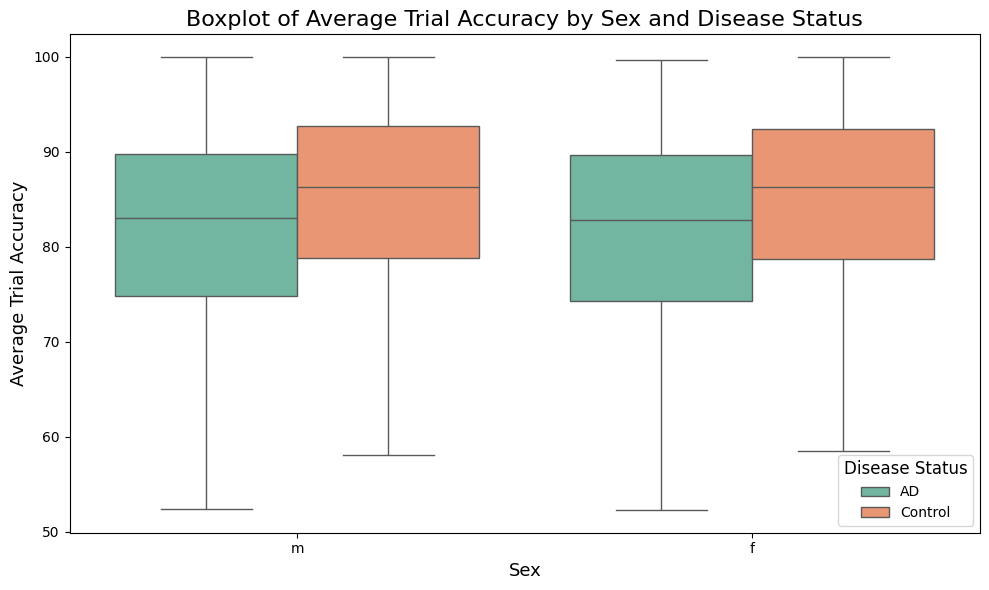

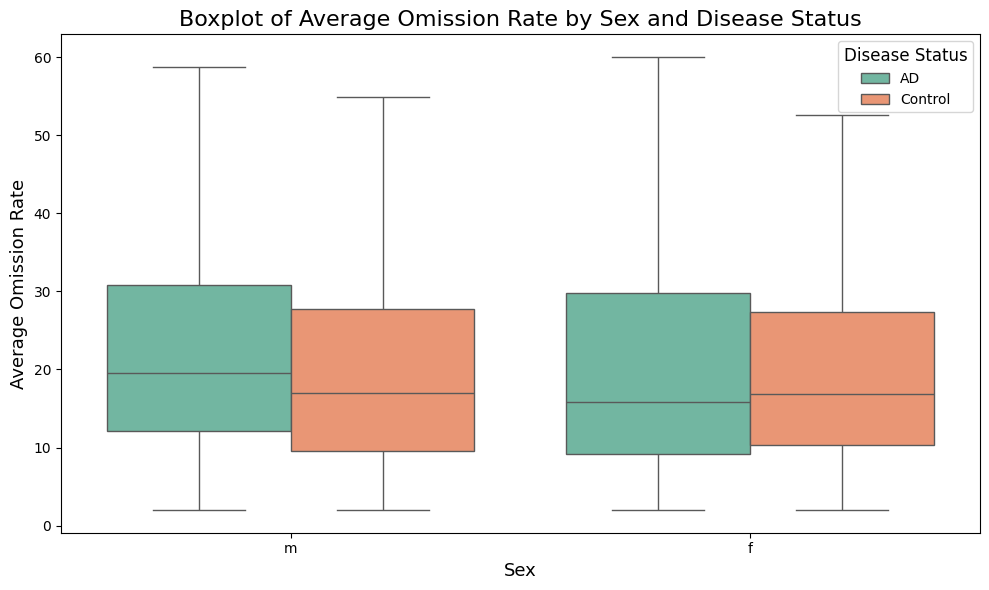

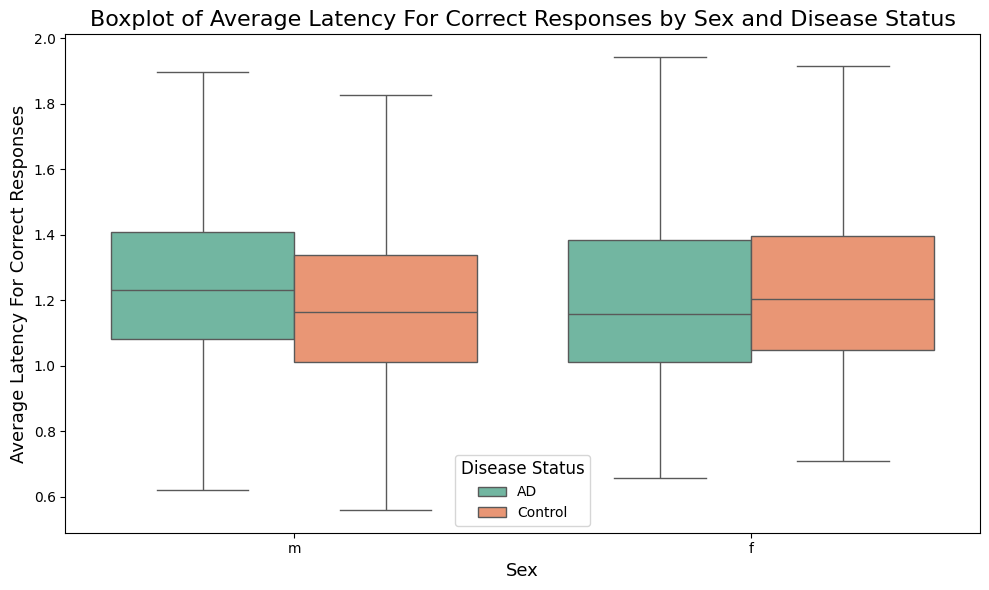

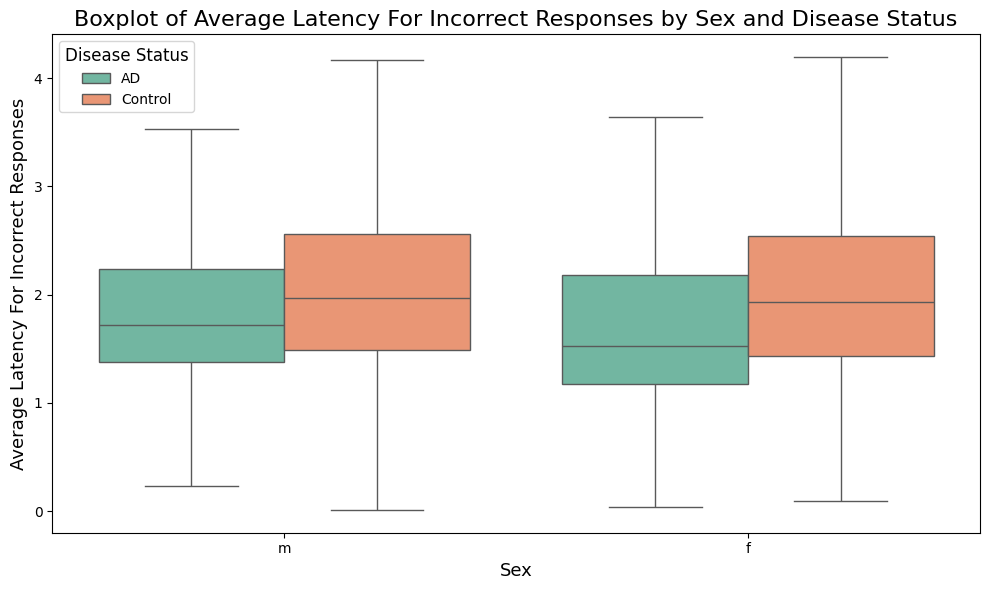

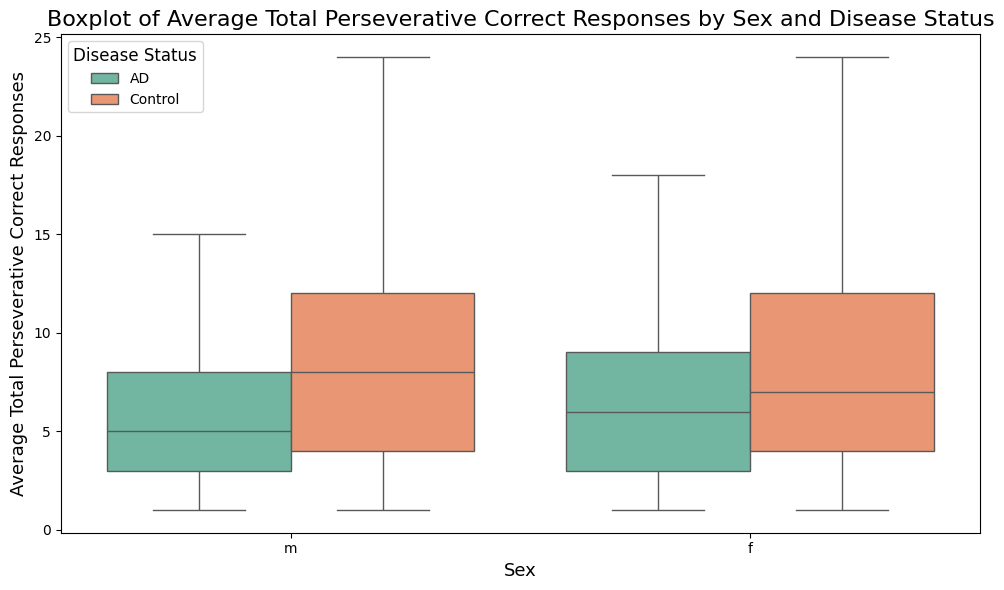

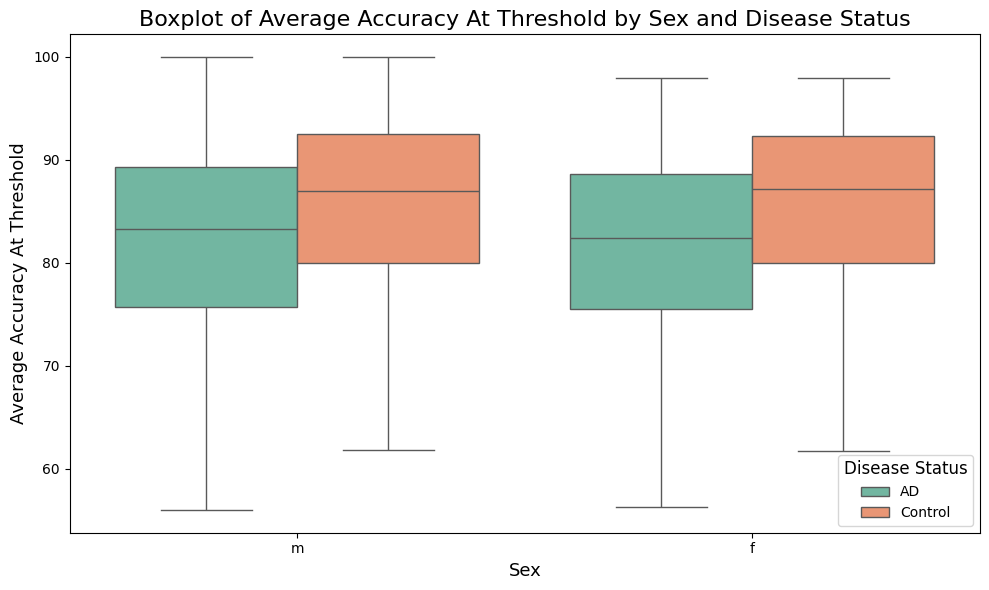

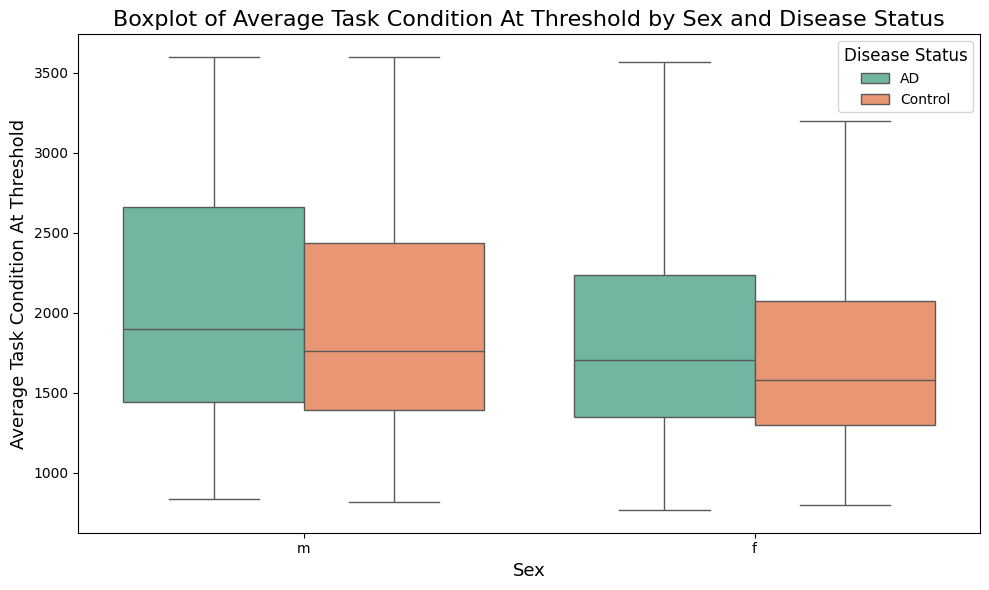

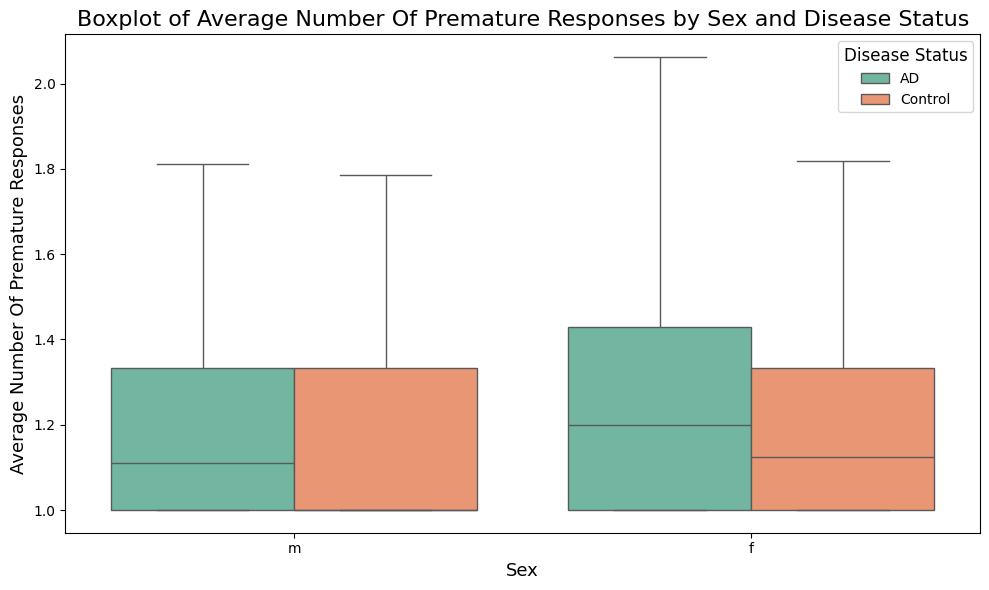

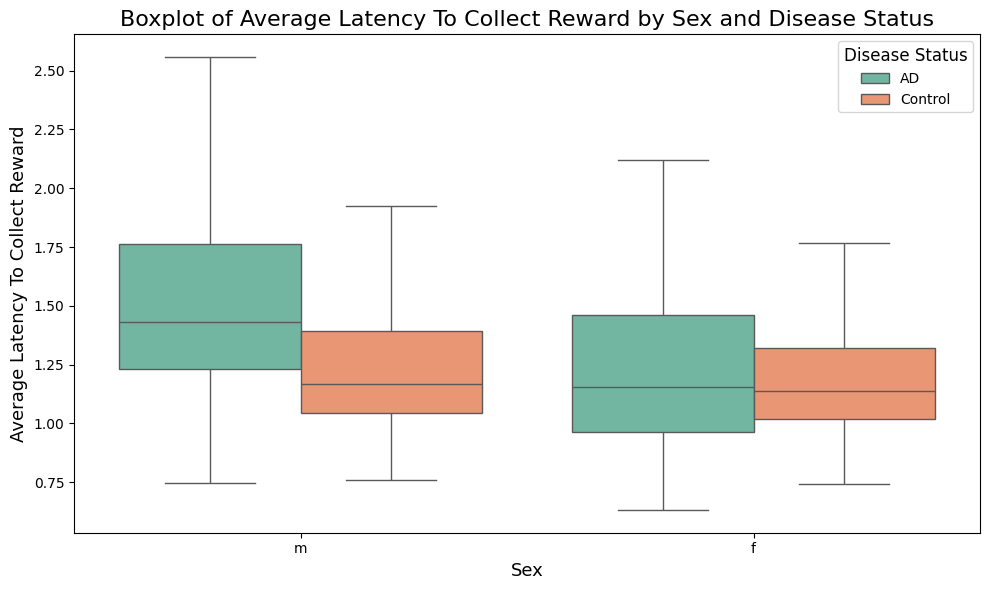

In [ ]:
for metric in five_choice_metrics:
    # 1. Generate the clean name once at the start of the loop
    clean_name = clean_metric_name(metric)

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=five_choice,
        x='Sex',
        y=metric,  # Keep the original 'metric' here so Seaborn can find the column
        hue='DiseaseStatus',
        dodge=True,
        showfliers=False,
        palette='Set2'
    )

    # 2. Use the 'clean_name' variable for your labels
    plt.title(f'Boxplot of {clean_name} by Sex and Disease Status', fontsize=16)
    plt.xlabel('Sex', fontsize=13)
    plt.ylabel(clean_name, fontsize=13)

    plt.legend(title='Disease Status', fontsize=10, title_fontsize=12)
    plt.tight_layout()
    plt.show()

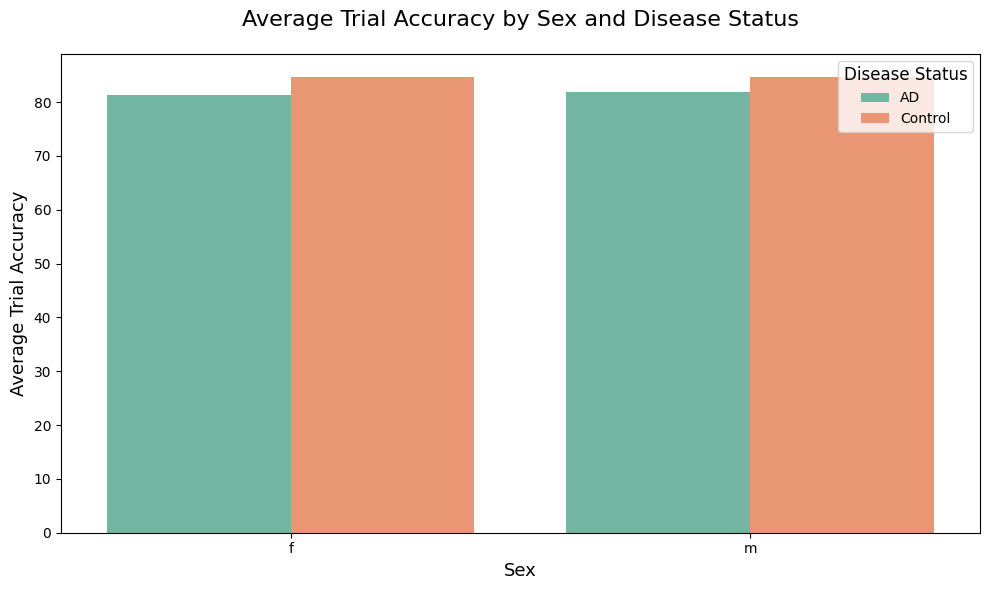

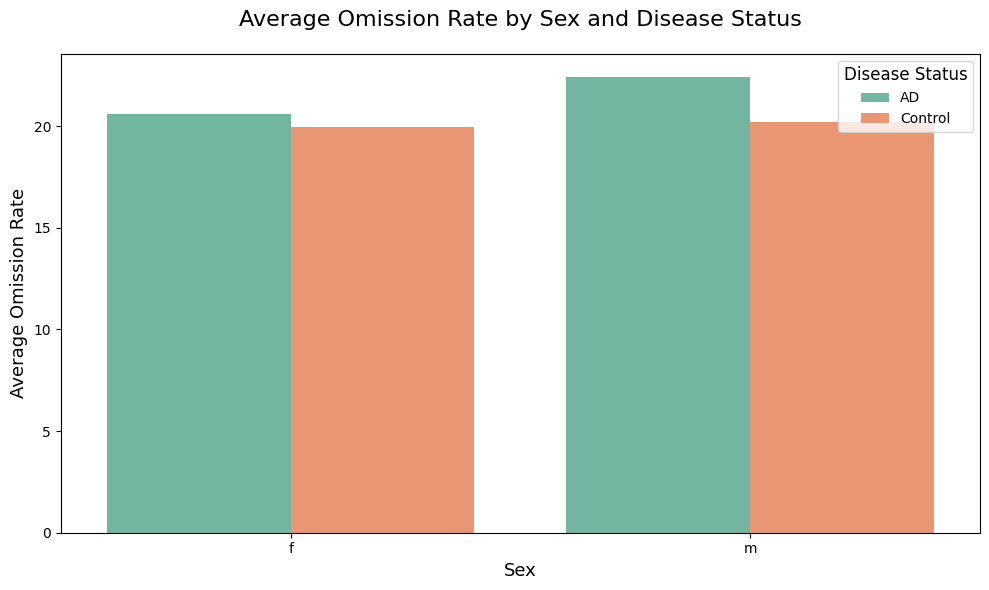

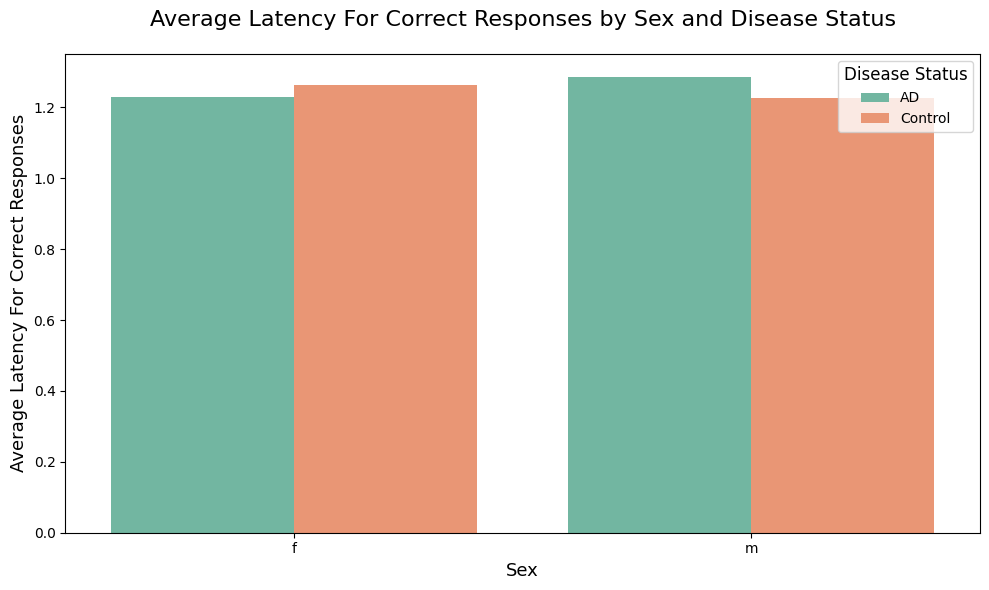

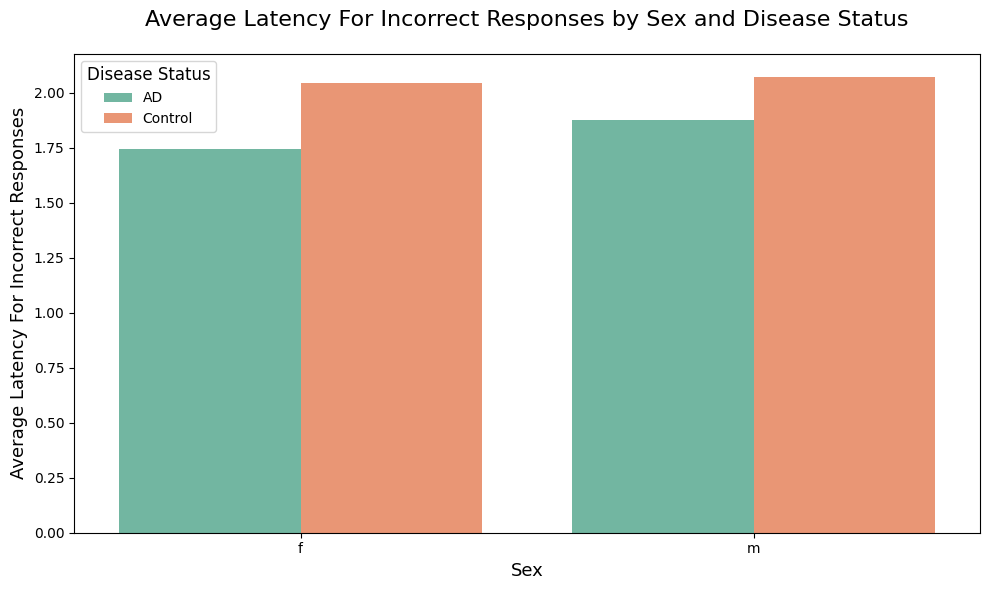

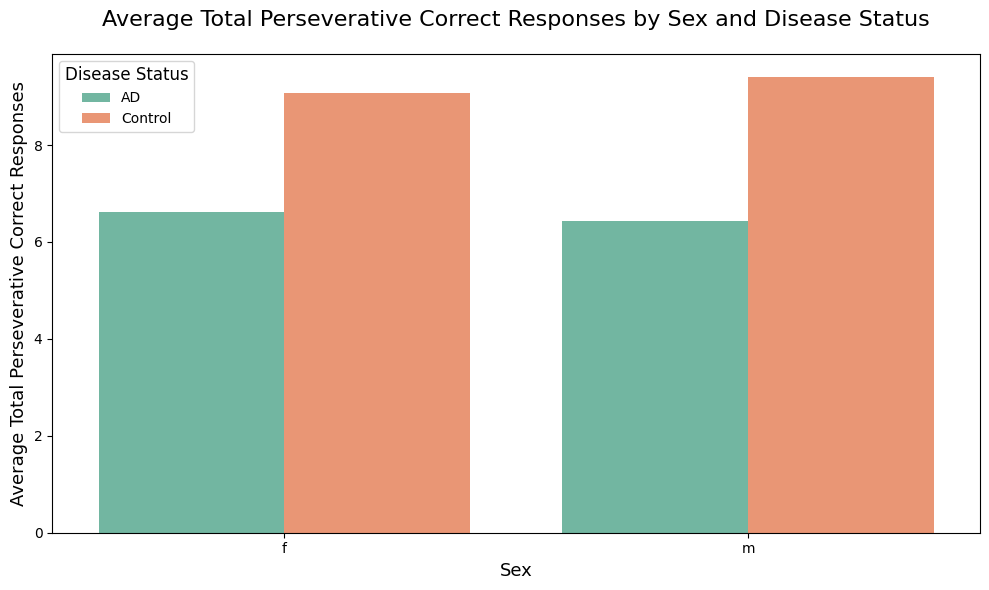

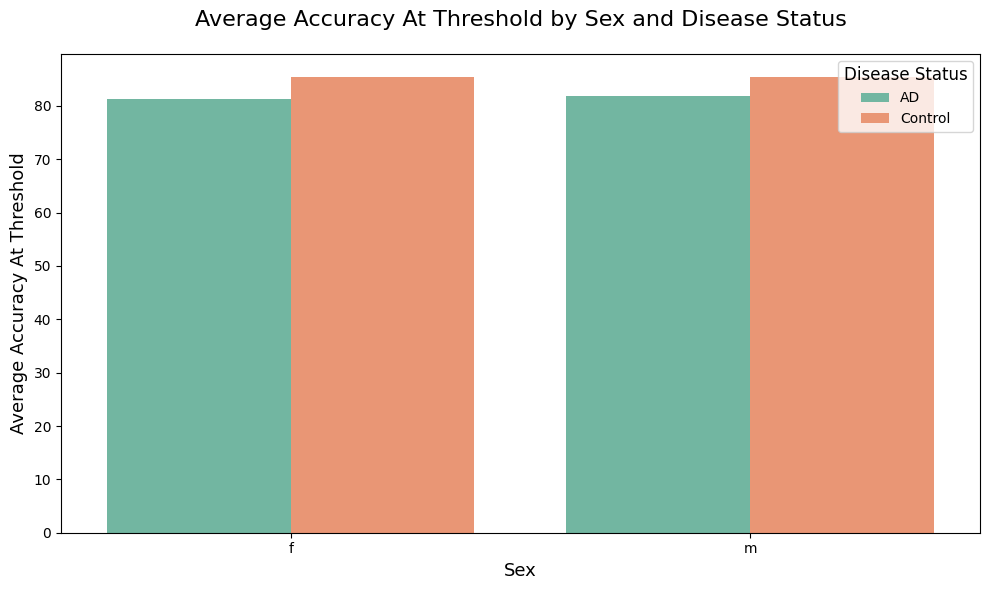

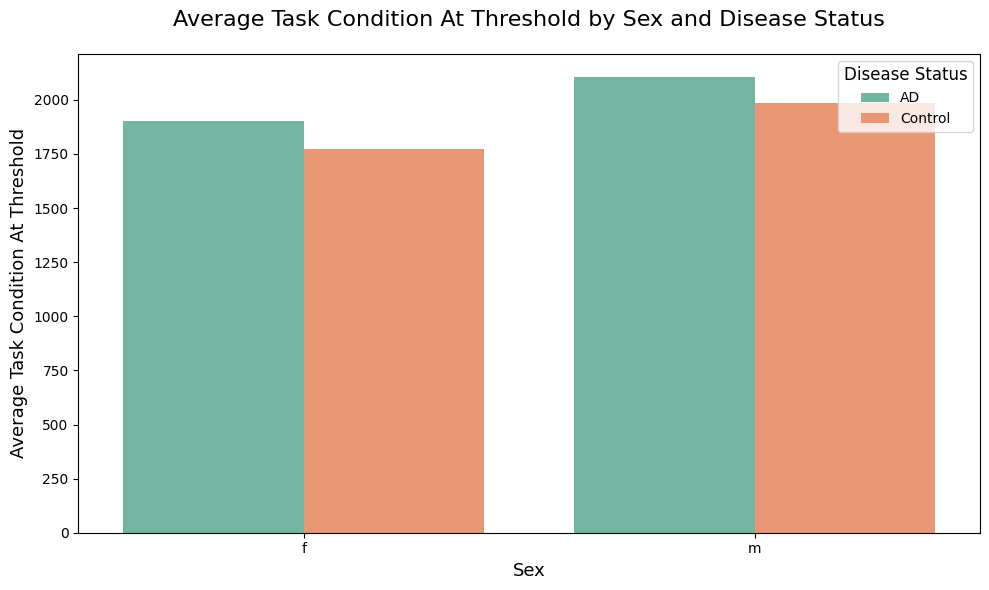

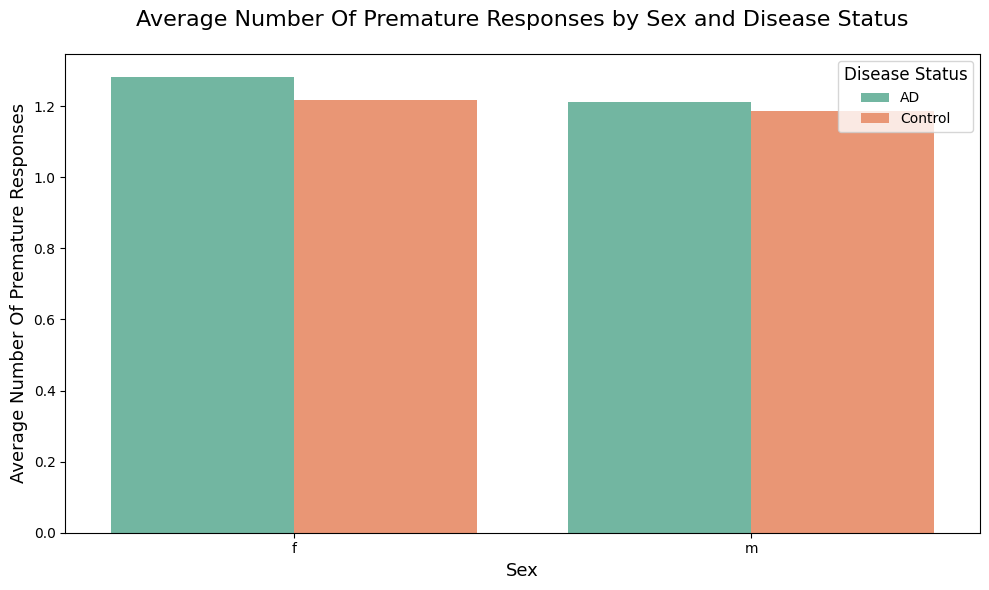

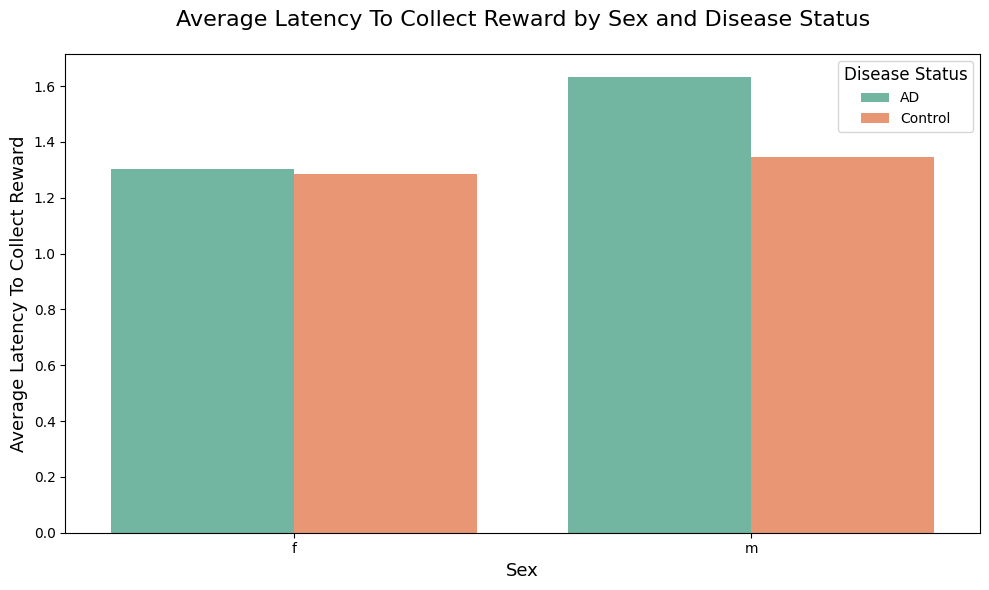

In [ ]:
for metric in five_choice_metrics:
    # 1. Clean the metric name using your function
    clean_name = clean_metric_name(metric)

    plt.figure(figsize=(10, 6))

    # Calculate the mean for the barplot
    avg_df = five_choice.groupby(['Sex', 'DiseaseStatus'])[metric].mean().reset_index()

    sns.barplot(
        data=avg_df,
        x='Sex',
        y=metric,  # Still use original metric name for the data mapping
        hue='DiseaseStatus',
        palette='Set2'
    )

    # 2. Use clean_name directly (it already starts with 'Average')
    plt.title(f'{clean_name} by Sex and Disease Status', fontsize=16, pad=20)
    plt.xlabel('Sex', fontsize=13)
    plt.ylabel(clean_name, fontsize=13)

    plt.legend(title='Disease Status', fontsize=10, title_fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
from scipy.stats import ttest_ind

# Initialize list
five_choice_results = []

# FIX: Use the exact lowercase labels 'm' and 'f' found in your output
for gender in ['m', 'f']:
    gender_df = five_choice[five_choice['Sex'] == gender]

    for metric in five_choice_metrics:
        vals_ad = gender_df[gender_df['DiseaseStatus'] == 'AD'][metric].dropna()
        vals_control = gender_df[gender_df['DiseaseStatus'] == 'Control'][metric].dropna()

        if len(vals_ad) >= 2 and len(vals_control) >= 2:
            t_stat, p_val = ttest_ind(vals_ad, vals_control, equal_var=False)
            five_choice_results.append({
                'gender': 'Female' if gender == 'f' else 'Male', # Standardize for dataframe
                'metric': metric,
                't_stat': t_stat,
                'p_val': p_val,
                'n_ad': len(vals_ad),
                'mean_ad': vals_ad.mean(),
                'std_ad': vals_ad.std(),
                'n_control': len(vals_control),
                'mean_control': vals_control.mean(),
                'std_control': vals_control.std()
            })

if not five_choice_results:
    print("ERROR: Check metric column names. No matches found.")
else:
    five_choice_results_df = pd.DataFrame(five_choice_results)
    # Apply Bonferroni and sorting
    five_choice_results_df['adj_p_val'] = (five_choice_results_df['p_val'] * 18).clip(upper=1.0)
    five_choice_results_df = five_choice_results_df.sort_values(['adj_p_val', 'metric'])
    print(five_choice_results_df)

    gender                                           metric    t_stat  \
4     Male                AVG_Perseverative Correct - Total -9.919698   
13  Female                AVG_Perseverative Correct - Total -8.189772   
14  Female                       AVG_Threshold - Accuracy % -7.489159   
5     Male                       AVG_Threshold - Accuracy % -7.379096   
8     Male   AVG_Trial Analysis - Reward Collection Latency  6.562992   
12  Female  AVG_Trial Analysis - Incorrect Response Latency -6.263455   
9   Female                   AVG_Trial Analysis - Accuracy% -5.525205   
0     Male                   AVG_Trial Analysis - Accuracy% -5.316788   
3     Male  AVG_Trial Analysis - Incorrect Response Latency -4.863891   
2     Male    AVG_Trial Analysis - Correct Response Latency  3.783962   
16  Female                   AVG_Trial Analysis - Premature  3.773071   
1     Male                   AVG_Trial Analysis - Omission%  3.194467   
15  Female                        AVG_Threshold - C

In [ ]:
five_choice_results_df['metric_clean'] = five_choice_results_df['metric'].apply(clean_metric_name)

In [ ]:
five_choice_results_df.to_csv('five_choice_results.csv', index=False)

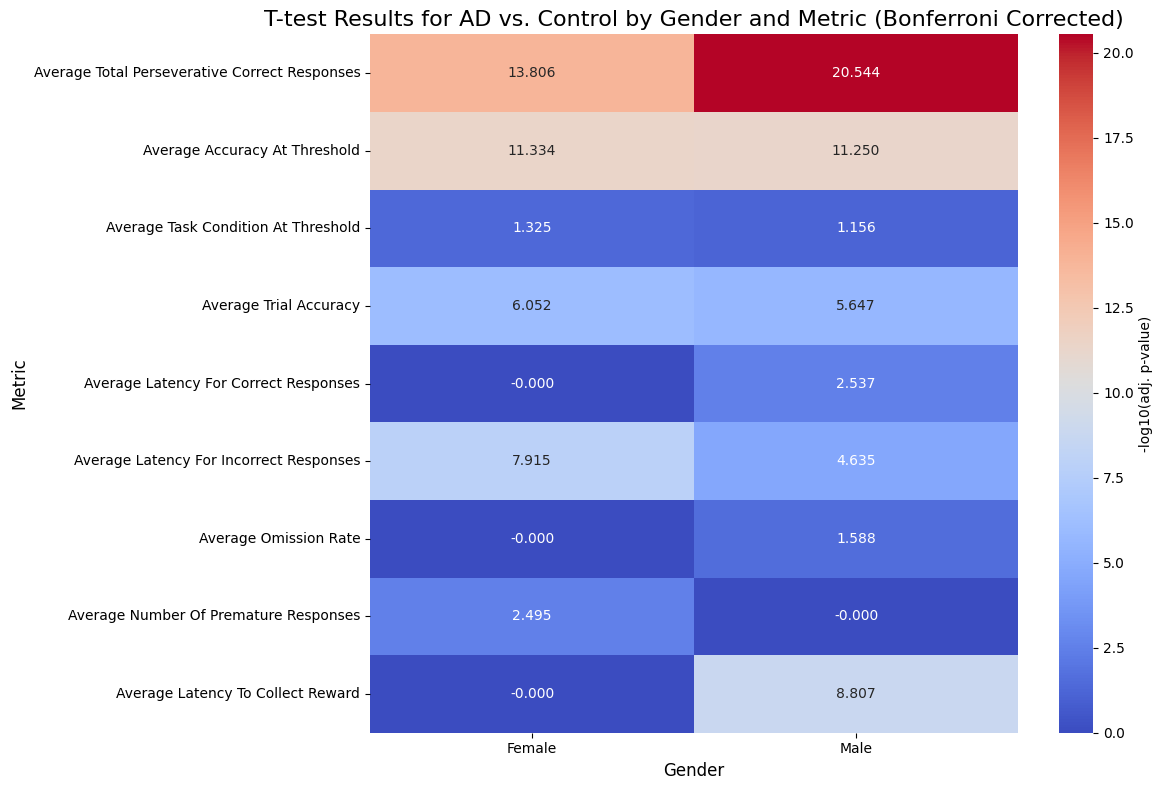

In [ ]:
# 1. Define specific order (Keep this as is)
custom_order = [
    "Average Total Perseverative Correct Responses",
    "Average Accuracy At Threshold",
    "Average Task Condition At Threshold",
    "Average Trial Accuracy",
    "Average Latency For Correct Responses",
    "Average Latency For Incorrect Responses",
    "Average Omission Rate",
    "Average Number Of Premature Responses",
    "Average Latency To Collect Reward"
]

# 2. FIX: Pivot using the ADJUSTED p-values to match Table 6
pval_matrix = five_choice_results_df.pivot(index='metric_clean', columns='gender', values='adj_p_val')

# 3. Reindex (Keep this as is)
pval_matrix = pval_matrix.reindex(custom_order)

# 4. Transform and Plot
# Use a small epsilon (e.g., 1e-10) if you have p-values that are exactly 0 to avoid infinity errors
log_pvals = -np.log10(pval_matrix.replace(0, 1e-10))

plt.figure(figsize=(12, 8))
sns.heatmap(
    log_pvals,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    # Ensure the label matches your data: Bonferroni Corrected
    cbar_kws={'label': '-log10(adj. p-value)'}
)

plt.title("T-test Results for AD vs. Control by Gender and Metric (Bonferroni Corrected)", fontsize=16)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Metric", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pandas as pd

# Assuming clean_metric_name is already defined as:
# def clean_metric_name(name): ... (the dictionary mapping version)

five_choice_clean = five_choice.copy()
anova_results_interaction = []

for metric in five_choice_metrics:
    # 1. Create a "safe" name for the OLS formula (no spaces/special chars)
    # We'll use this to temporarily rename the column in a subsetted dataframe
    safe_name = "target_metric"

    # 2. Prepare data for this specific metric
    # We rename the column to 'target_metric' so the OLS formula is ALWAYS the same
    df = five_choice_clean[['DiseaseStatus', 'Sex', metric]].dropna()
    df = df.rename(columns={metric: safe_name})

    # Check for sufficient data
    if set(df['DiseaseStatus'].unique()) >= {'Control', 'AD'} and set(df['Sex'].unique()) >= {'m', 'f'}:

        # 3. Fit the model using the safe column name
        formula = f'{safe_name} ~ C(DiseaseStatus) * C(Sex)'
        model = ols(formula, data=df).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)

        # 4. Store results using both the raw key and the clean display name
        anova_results_interaction.append({
            'metric': metric,                         # Raw ID
            'metric_clean': clean_metric_name(metric), # Pretty Name

            'sum_sq_group': anova_table.loc['C(DiseaseStatus)', 'sum_sq'],
            'F_group': anova_table.loc['C(DiseaseStatus)', 'F'],
            'p_group': anova_table.loc['C(DiseaseStatus)', 'PR(>F)'],

            'sum_sq_gender': anova_table.loc['C(Sex)', 'sum_sq'],
            'F_gender': anova_table.loc['C(Sex)', 'F'],
            'p_gender': anova_table.loc['C(Sex)', 'PR(>F)'],

            'sum_sq_interaction': anova_table.loc['C(DiseaseStatus):C(Sex)', 'sum_sq'],
            'F_interaction': anova_table.loc['C(DiseaseStatus):C(Sex)', 'F'],
            'p_interaction': anova_table.loc['C(DiseaseStatus):C(Sex)', 'PR(>F)']
        })

# 5. Create DataFrame and sort
anova_interaction_df = pd.DataFrame(anova_results_interaction).sort_values('p_interaction')

# Display with the clean names first
cols = ['metric_clean'] + [c for c in anova_interaction_df.columns if c not in ['metric', 'metric_clean']]
print(anova_interaction_df[cols].to_string(index=False))

                                 metric_clean  sum_sq_group    F_group      p_group  sum_sq_gender  F_gender     p_gender  sum_sq_interaction  F_interaction  p_interaction
            Average Latency To Collect Reward  1.939845e+01  35.054821 3.533859e-09   1.542209e+01 27.869171 1.381817e-07           12.392734      22.394839       0.000002
        Average Latency For Correct Responses  2.585481e-01   2.547200 1.105855e-01   7.194819e-02  0.708829 3.998937e-01            1.454885      14.333440       0.000156
        Average Number Of Premature Responses  1.305551e+00  16.804246 4.243746e-05   1.507551e+00 19.404259 1.091278e-05            0.285523       3.675077       0.055318
      Average Latency For Incorrect Responses  4.069290e+01  58.864044 2.208320e-14   2.891471e+00  4.182638 4.091913e-02            1.769983       2.560357       0.109669
                        Average Omission Rate  1.568017e+03   8.663380 3.269292e-03   3.969971e+02  2.193431 1.386956e-01          430.13188

In [ ]:
anova_interaction_df.to_csv('anova_interaction_five_choice.csv', index=False)

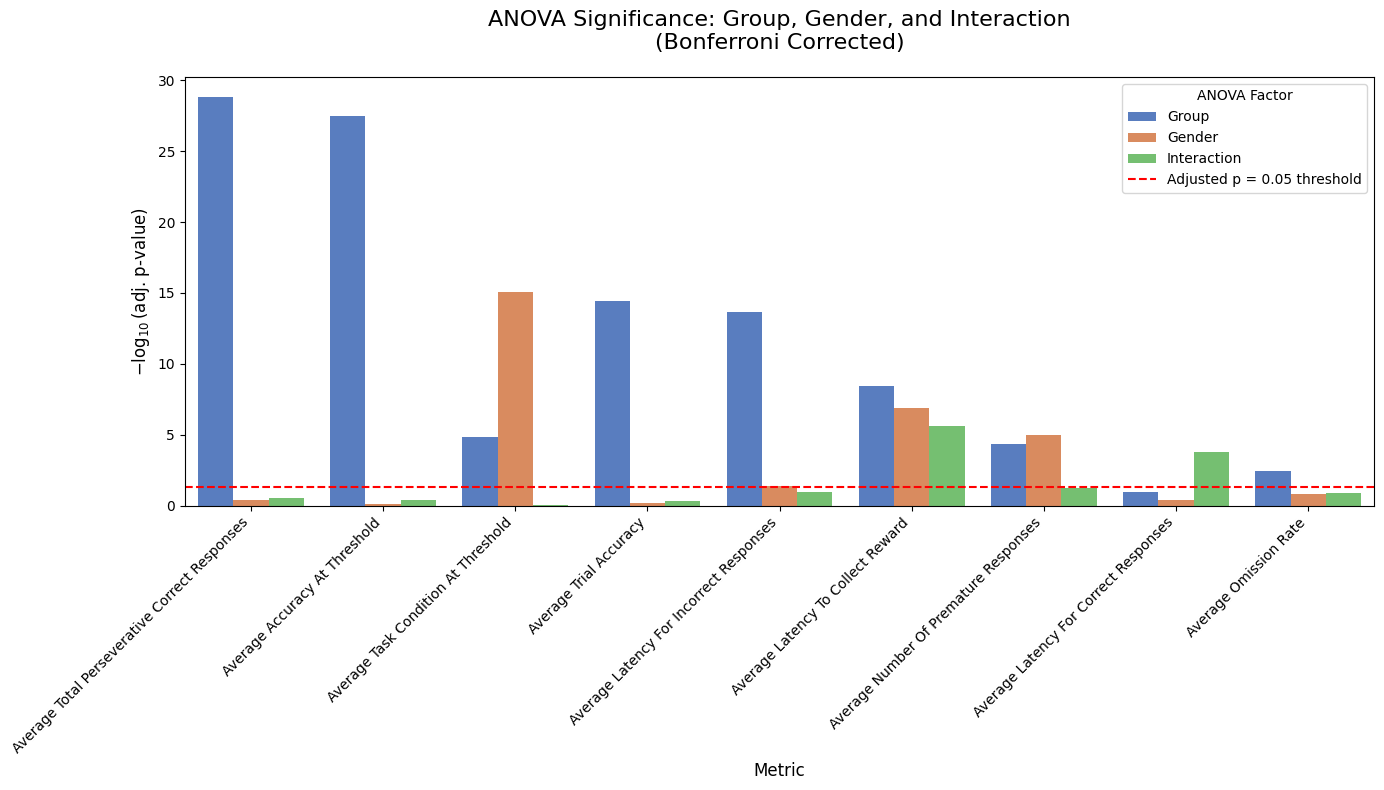

In [ ]:
# 1. Reuse your descriptive cleaning function (ensure it matches your custom list)
def clean_metric_name(name):
    mapping = {
        "AVG_Perseverative Correct - Total": "Average Total Perseverative Correct Responses",
        "AVG_Threshold - Accuracy %": "Average Accuracy At Threshold",
        "AVG_Threshold - Condition": "Average Task Condition At Threshold",
        "AVG_Trial Analysis - Accuracy%": "Average Trial Accuracy",
        "AVG_Trial Analysis - Correct Response Latency": "Average Latency For Correct Responses",
        "AVG_Trial Analysis - Incorrect Response Latency": "Average Latency For Incorrect Responses",
        "AVG_Trial Analysis - Omission%": "Average Omission Rate",
        "AVG_Trial Analysis - Premature": "Average Number Of Premature Responses",
        "AVG_Trial Analysis - Reward Collection Latency": "Average Latency To Collect Reward"
    }
    # Return mapping if found, otherwise title-case the raw name
    return mapping.get(name, name.replace('_', ' ').replace('-', ' ').title())

# 2. Melt using the CORRECTED p-values
# (These were created in your step 3: p_group, p_gender, p_interaction)
melted_df = pd.melt(
    anova_interaction_df,
    id_vars=['metric'],
    value_vars=['p_group', 'p_gender', 'p_interaction'],
    var_name='factor',
    value_name='p_adj'
)

# 3. Clean up Factor labels
melted_df['factor'] = melted_df['factor'].replace({
    'p_group': 'Group',
    'p_gender': 'Gender',
    'p_interaction': 'Interaction'
})

# 4. Apply -log10 transformation (absolute to remove -0.0)
melted_df['-log10(p_adj)'] = (-np.log10(melted_df['p_adj'].replace(0, 1e-20))).abs()

# 5. Apply the clean naming function
melted_df['metric_clean'] = melted_df['metric'].apply(clean_metric_name)

# 6. Handle Plot Ordering (Order by most significant p-value found in ANY category)
metric_order_raw = (anova_interaction_df
                .set_index('metric')[['p_group', 'p_gender', 'p_interaction']]
                .min(axis=1)
                .sort_values()
                .index.tolist())

metric_order_clean = [clean_metric_name(m) for m in metric_order_raw]

melted_df['metric_clean'] = pd.Categorical(
    melted_df['metric_clean'],
    categories=metric_order_clean,
    ordered=True
)

# 7. Final Visualization
plt.figure(figsize=(14, 8))
sns.barplot(
    data=melted_df,
    x='metric_clean',
    y='-log10(p_adj)',
    hue='factor',
    palette='muted'
)

# Red threshold line for significance (alpha = 0.05)
plt.axhline(-np.log10(0.05), color='red', linestyle='--', label='Adjusted p = 0.05 threshold')

plt.ylabel(r'$-\log_{10}(\text{adj. p-value})$', fontsize=12)
plt.xlabel('Metric', fontsize=12)
plt.title('ANOVA Significance: Group, Gender, and Interaction\n(Bonferroni Corrected)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.legend(title='ANOVA Factor', loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * np.std(x, ddof=1) ** 2 + (ny - 1) * np.std(y, ddof=1) ** 2) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

summary_table = []

for metric in five_choice_metrics:
    for sex in ['m', 'f']:
        control_vals = five_choice[(five_choice['DiseaseStatus']=='Control') &
                                              (five_choice['Sex']==sex)][metric].dropna()
        ad_vals = five_choice[(five_choice['DiseaseStatus']=='AD') &
                                          (five_choice['Sex']==sex)][metric].dropna()
        if len(control_vals) > 0 and len(ad_vals) > 0:
            t_stat, p_val = ttest_ind(ad_vals, control_vals, equal_var=False)
            pct_change = (ad_vals.mean() - control_vals.mean()) / control_vals.mean() * 100
            d = cohen_d(ad_vals, control_vals)
            summary_table.append({
                'Metric': metric,
                'Sex': sex,
                'Control Mean ± SD': f"{control_vals.mean():.2f} ± {control_vals.std():.2f}",
                'AD Mean ± SD': f"{ad_vals.mean():.2f} ± {ad_vals.std():.2f}",
                '% Change from Control': f"{pct_change:.2f}%",
                't-stat': t_stat,
                'p-value': p_val,
                "Cohen's d": d
            })

summary_df = pd.DataFrame(summary_table)
summary_df


,Metric,Sex,Control Mean ± SD,AD Mean ± SD,% Change from Control,t-stat,p-value,Cohen's d
0,AVG_Trial Analysis - Accuracy%,m,84.75 ± 10.28,81.91 ± 10.43,-3.35%,-5.316788,1.252710e-07,-0.274476
1,AVG_Trial Analysis - Accuracy%,f,84.73 ± 9.86,81.28 ± 11.15,-4.08%,-5.525205,4.932025e-08,-0.339407
2,AVG_Trial Analysis - Omission%,m,20.21 ± 13.48,22.43 ± 13.62,11.03%,3.194467,1.436241e-03,0.164743
3,AVG_Trial Analysis - Omission%,f,19.97 ± 12.85,20.60 ± 14.98,3.15%,0.752502,4.520538e-01,0.046975
4,AVG_Trial Analysis - Correct Response Latency,m,1.23 ± 0.32,1.29 ± 0.31,4.96%,3.783962,1.614546e-04,0.192729
5,AVG_Trial Analysis - Correct Response Latency,f,1.26 ± 0.32,1.23 ± 0.33,-2.56%,-1.722961,8.537922e-02,-0.100422
6,AVG_Trial Analysis - Incorrect Response Latency,m,2.07 ± 0.84,1.88 ± 0.77,-9.60%,-4.863891,1.287700e-06,-0.244600
7,AVG_Trial Analysis - Incorrect Response Latency,f,2.04 ± 0.85,1.74 ± 0.83,-14.76%,-6.263455,6.759207e-10,-0.355825
8,AVG_Perseverative Correct - Total,m,9.41 ± 6.96,6.43 ± 5.08,-31.65%,-9.919698,1.587932e-22,-0.470576
9,AVG_Perseverative Correct - Total,f,9.08 ± 6.64,6.62 ± 4.67,-27.02%,-8.189772,8.684491e-16,-0.393074


In [ ]:
summary_df.to_csv('baseline_results_table_five_choice', index=False)